## Step 0: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Step 1: Data Loading

In [2]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
dataset = pd.read_csv(url)
dataset.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## Step 2: Data Preparation

In [3]:
df = dataset.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

### Drop null values

In [4]:
df = df.dropna()
df.count()

Date             56420
Location         56420
MinTemp          56420
MaxTemp          56420
Rainfall         56420
Evaporation      56420
Sunshine         56420
WindGustDir      56420
WindGustSpeed    56420
WindDir9am       56420
WindDir3pm       56420
WindSpeed9am     56420
WindSpeed3pm     56420
Humidity9am      56420
Humidity3pm      56420
Pressure9am      56420
Pressure3pm      56420
Cloud9am         56420
Cloud3pm         56420
Temp9am          56420
Temp3pm          56420
RainToday        56420
RainTomorrow     56420
dtype: int64

### Check unique locations

In [5]:
df.Location.value_counts()

Location
Darwin              3062
Perth               3025
Brisbane            2953
MelbourneAirport    2929
PerthAirport        2913
SydneyAirport       2870
Watsonia            2730
Mildura             2594
MountGambier        2465
NorfolkIsland       2464
Cairns              2444
Townsville          2419
WaggaWagga          2416
AliceSprings        2223
Nuriootpa           2008
Hobart              1939
Moree               1913
Melbourne           1898
Portland            1863
Woomera             1734
Sydney              1690
Sale                1678
CoffsHarbour        1380
Williamtown         1198
Canberra            1078
Cobar                534
Name: count, dtype: int64

### Choose Melbourne and nearby areas

In [6]:
df = df[df.Location.isin(['Melbourne', 'MelbourneAirport', 'Watsonia'])]
df.count()

Date             7557
Location         7557
MinTemp          7557
MaxTemp          7557
Rainfall         7557
Evaporation      7557
Sunshine         7557
WindGustDir      7557
WindGustSpeed    7557
WindDir9am       7557
WindDir3pm       7557
WindSpeed9am     7557
WindSpeed3pm     7557
Humidity9am      7557
Humidity3pm      7557
Pressure9am      7557
Pressure3pm      7557
Cloud9am         7557
Cloud3pm         7557
Temp9am          7557
Temp3pm          7557
RainToday        7557
RainTomorrow     7557
dtype: int64

### Extract season and drop date 

In [7]:
def date_to_season(date):
    month = date.month
    match month:
        case 12 | 1 | 2:
            return 'Summer'
        case 3 | 4 | 5:
            return 'Fall'
        case 6 | 7 | 8:
            return 'Winter'
        case 9 | 10 | 11:
            return 'spring'

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Season'] = df['Date'].apply(date_to_season)
df = df.drop(columns=['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7557 entries, 64191 to 80997
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       7557 non-null   object 
 1   MinTemp        7557 non-null   float64
 2   MaxTemp        7557 non-null   float64
 3   Rainfall       7557 non-null   float64
 4   Evaporation    7557 non-null   float64
 5   Sunshine       7557 non-null   float64
 6   WindGustDir    7557 non-null   object 
 7   WindGustSpeed  7557 non-null   float64
 8   WindDir9am     7557 non-null   object 
 9   WindDir3pm     7557 non-null   object 
 10  WindSpeed9am   7557 non-null   float64
 11  WindSpeed3pm   7557 non-null   float64
 12  Humidity9am    7557 non-null   float64
 13  Humidity3pm    7557 non-null   float64
 14  Pressure9am    7557 non-null   float64
 15  Pressure3pm    7557 non-null   float64
 16  Cloud9am       7557 non-null   float64
 17  Cloud3pm       7557 non-null   float64
 18  Temp9am 

### Define features and target

In [9]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

In [10]:
y.value_counts()

RainTomorrow
No     5766
Yes    1791
Name: count, dtype: int64

## Step 3: Model Selection and Training

### Split data into training and test sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

### Data scaling and encoding

In [12]:
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

### Model selection

In [13]:
# Choose RandomForestClassifier as the model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [None, 10, 15, 20, 25],
}

cv = StratifiedKFold(shuffle=True)

### Model training

In [14]:
model = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', verbose=2)
model.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END classifier__max_depth=None, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__n_estimators=100; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__n_estimators=100; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__n_estimators=100; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__n_estimators=100; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__n_estimators=100; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__n_estimators=150; total time=   0.8

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Evaporation',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          'Humidity3pm',
                                                                          'Pressure9am',
                                                                          'Pressure3pm',
                                                                          'Cloud9am',
                                                                          'Cloud3pm',
                                                                          'Temp9am',
                                                                          'Temp3pm']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Location',
                                                                          'WindGustDir',
                                                                          'WindDir9am',
                                                                          'WindDir3pm',
                                                                          'RainToday',
                                                                          'Season'])])),
                                       ('classifier',
                                        RandomForestClassifier())]),
             param_grid={'classifier__max_depth': [None, 10, 15, 20, 25],
                         'classifier__n_estimators': [50, 100, 150]},
             scoring='accuracy', verbose=2)

### Print best parameters and validation score

In [15]:
print(f'Best parameters = {model.best_params_}')
print(f'Best score = {model.best_score_}')

Best parameters = {'classifier__max_depth': 25, 'classifier__n_estimators': 150}
Best score = 0.8504549214226633


## Step 4: Model Evaluation

### Model precision, recall, F1-score, and accuracy

In [16]:
y_pred = model.predict(X_test)
print('Classification report:')
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

          No       0.87      0.96      0.92      1154
         Yes       0.82      0.54      0.65       358

    accuracy                           0.86      1512
   macro avg       0.85      0.75      0.78      1512
weighted avg       0.86      0.86      0.85      1512



### Confusion matrix

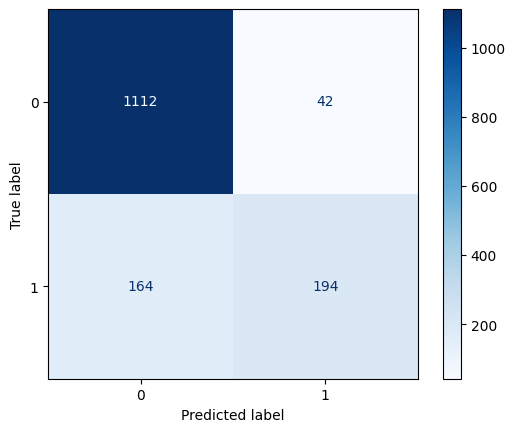

In [17]:
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix)
disp.plot(cmap='Blues')